saved figs/m3_scaling.pdf
ASCIR:       [0.7273, 0.697, 0.6591]
B-Local:     [0.7727, 0.7576, 0.7727]
B-Broadcast: [0.0, 0.0, 0.0]


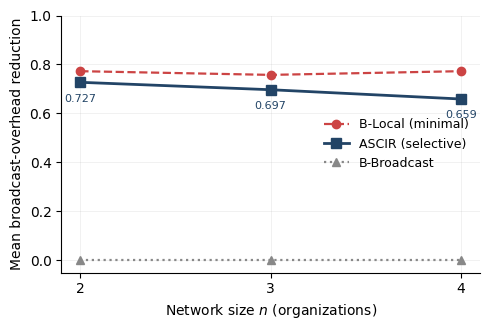

In [1]:
# Cell 1 — M3 scaling curve: the three-baseline comparison
import json, matplotlib.pyplot as plt
from pathlib import Path

R = Path.home() / "research/ascir/experiments/results"

def load(metric, n):
    return json.load(open(R / f"{metric}_n{n}.json"))

ns = [2, 3, 4]
ascir   = [load("m3", n)["summary"]["mean_ascir_reduction"]  for n in ns]
blocal  = [json.load(open(R / f"b_local_n{n}.json"))["summary"]["mean_blocal_reduction"] for n in ns]
broadcast = [0.0, 0.0, 0.0]

fig, ax = plt.subplots(figsize=(5.0, 3.4))
ax.plot(ns, blocal,   "o--", color="#c44", label="B-Local (minimal)", linewidth=1.6, markersize=6)
ax.plot(ns, ascir,    "s-",  color="#246", label="ASCIR (selective)", linewidth=2.0, markersize=7)
ax.plot(ns, broadcast,"^:",  color="#888", label="B-Broadcast", linewidth=1.6, markersize=6)

ax.set_xlabel("Network size $n$ (organizations)")
ax.set_ylabel("Mean broadcast-overhead reduction")
ax.set_xticks(ns)
ax.set_ylim(-0.05, 1.0)
ax.legend(frameon=False, fontsize=9, loc="center right")
ax.grid(True, alpha=0.25, linewidth=0.5)
ax.spines[["top","right"]].set_visible(False)
for n, v in zip(ns, ascir):
    ax.annotate(f"{v:.3f}", (n, v), textcoords="offset points", xytext=(0,-14),
                fontsize=8, ha="center", color="#246")

fig.tight_layout()
out = Path.home() / "research/ascir/figs"
out.mkdir(exist_ok=True)
fig.savefig(out / "m3_scaling.pdf", bbox_inches="tight")
fig.savefig(out / "m3_scaling.png", dpi=150, bbox_inches="tight")
print("saved figs/m3_scaling.pdf")
print(f"ASCIR:       {ascir}")
print(f"B-Local:     {blocal}")
print(f"B-Broadcast: {broadcast}")

saved figs/m1_confusion.pdf
TP=15 TN=30 FP=0 FN=0 | acc=1.0 prec=1.0 rec=1.0


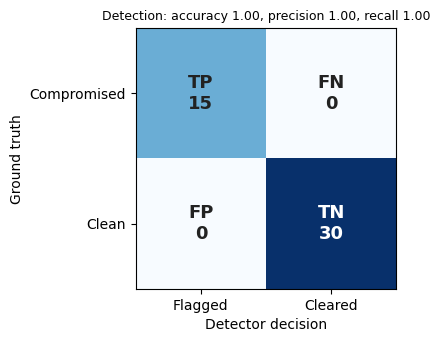

In [2]:
# Cell 2 — M1 confusion matrix
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

R = Path.home() / "research/ascir/experiments/results"
m1 = json.load(open(R / "m1_n4.json"))["summary"]
TP, TN, FP, FN = m1["TP"], m1["TN"], m1["FP"], m1["FN"]

# rows = actual (compromised, clean); cols = predicted (flagged, cleared)
cm = np.array([[TP, FN],   # actual compromised: flagged(TP), missed(FN)
               [FP, TN]])   # actual clean:       flagged(FP), cleared(TN)

fig, ax = plt.subplots(figsize=(4.0, 3.6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())

labels = [["TP", "FN"], ["FP", "TN"]]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        # white text on dark cells, dark on light
        color = "white" if val > cm.max()*0.5 else "#222"
        ax.text(j, i, f"{labels[i][j]}\n{val}", ha="center", va="center",
                fontsize=13, color=color, fontweight="bold")

ax.set_xticks([0,1]); ax.set_xticklabels(["Flagged", "Cleared"])
ax.set_yticks([0,1]); ax.set_yticklabels(["Compromised", "Clean"])
ax.set_xlabel("Detector decision"); ax.set_ylabel("Ground truth")
ax.set_title(f"Detection: accuracy {m1['accuracy']:.2f}, "
             f"precision {m1['precision']:.2f}, recall {m1['recall']:.2f}",
             fontsize=9)
fig.tight_layout()

out = Path.home() / "research/ascir/figs"
fig.savefig(out / "m1_confusion.pdf", bbox_inches="tight")
fig.savefig(out / "m1_confusion.png", dpi=150, bbox_inches="tight")
print("saved figs/m1_confusion.pdf")
print(f"TP={TP} TN={TN} FP={FP} FN={FN} | acc={m1['accuracy']} prec={m1['precision']} rec={m1['recall']}")

saved figs/m4_latency.pdf
median: [101.32, 140.39, 115.17]
p95:    [109.12, 165.99, 138.4]


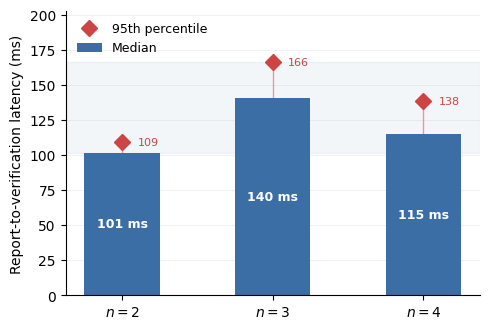

In [5]:
# Cell 3 (revised) — cleaner label placement
import json, matplotlib.pyplot as plt
from pathlib import Path

R = Path.home() / "research/ascir/experiments/results"
ns = [2, 3, 4]
med = [json.load(open(R / f"m4_n{n}.json"))["median_ms"] for n in ns]
p95 = [json.load(open(R / f"m4_n{n}.json"))["p95_ms"]    for n in ns]

fig, ax = plt.subplots(figsize=(5.0, 3.4))
x = list(range(len(ns)))

ax.bar(x, med, width=0.5, color="#3a6ea5", label="Median", zorder=2)
ax.plot(x, p95, "D", color="#c44", markersize=8, label="95th percentile", zorder=3)

for xi, m, p in zip(x, med, p95):
    ax.plot([xi, xi], [m, p], color="#c44", linewidth=1.0, alpha=0.5, zorder=1)
    # median label INSIDE the bar, well below the top, clearly on blue
    ax.annotate(f"{m:.0f} ms", (xi, m*0.5), ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    # p95 label to the right of the diamond
    ax.annotate(f"{p:.0f}", (xi, p), textcoords="offset points", xytext=(11,0),
                ha="left", va="center", fontsize=8, color="#c44")

ax.set_xticks(x); ax.set_xticklabels([f"$n={n}$" for n in ns])
ax.set_ylabel("Report-to-verification latency (ms)")
ax.set_ylim(0, max(p95) * 1.22)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.grid(True, axis="y", alpha=0.25, linewidth=0.5)
ax.spines[["top","right"]].set_visible(False)
ax.axhspan(min(med), max(p95), color="#3a6ea5", alpha=0.06, zorder=0)

fig.tight_layout()
out = Path.home() / "research/ascir/figs"
fig.savefig(out / "m4_latency.pdf", bbox_inches="tight")
fig.savefig(out / "m4_latency.png", dpi=150, bbox_inches="tight")
print("saved figs/m4_latency.pdf")
print(f"median: {med}")
print(f"p95:    {p95}")

In [6]:
# Cell — check graphviz availability
try:
    import graphviz
    print("graphviz python package: OK")
except ImportError:
    print("need to install: run  !pip install graphviz --break-system-packages")

need to install: run  !pip install graphviz --break-system-packages


In [7]:
!pip install graphviz --break-system-packages